In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 10.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [ ]:
# Nuevas variables difusas
temperature = ctrl.Antecedent(np.arange(0, 41, 1), 'temperature')
humidity = ctrl.Antecedent(np.arange(0, 101, 1), 'humidity')
fan_speed = ctrl.Consequent(np.arange(0, 101, 1), 'fan_speed')

# Funciones de membresía de temperatura
temperature['cold'] = fuzz.trapmf(temperature.universe, [0, 0, 15, 20])
temperature['warm'] = fuzz.trimf(temperature.universe, [15, 25, 35])
temperature['hot'] = fuzz.trapmf(temperature.universe, [30, 35, 40, 40])

# Funciones de membresía de humedad
humidity['low'] = fuzz.trapmf(humidity.universe, [0, 0, 30, 40])
humidity['medium'] = fuzz.trimf(humidity.universe, [30, 50, 70])
humidity['high'] = fuzz.trapmf(humidity.universe, [60, 70, 100, 100])

# Funciones de membresía de velocidad del ventilador
fan_speed['off'] = fuzz.trapmf(fan_speed.universe, [0, 0, 20, 30])
fan_speed['low'] = fuzz.trimf(fan_speed.universe, [20, 40, 60])
fan_speed['medium'] = fuzz.trimf(fan_speed.universe, [40, 60, 80])
fan_speed['high'] = fuzz.trapmf(fan_speed.universe, [70, 90, 100, 100])

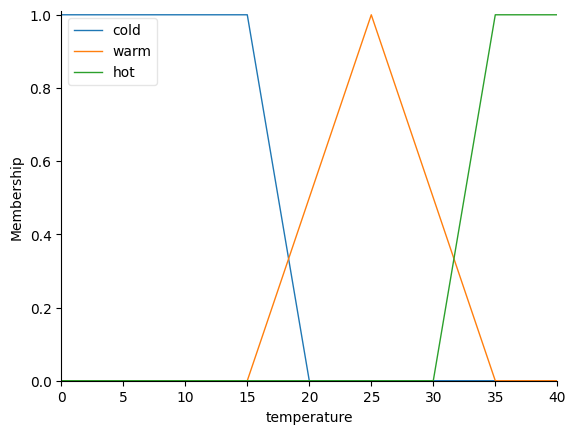

In [ ]:
temperature.view()

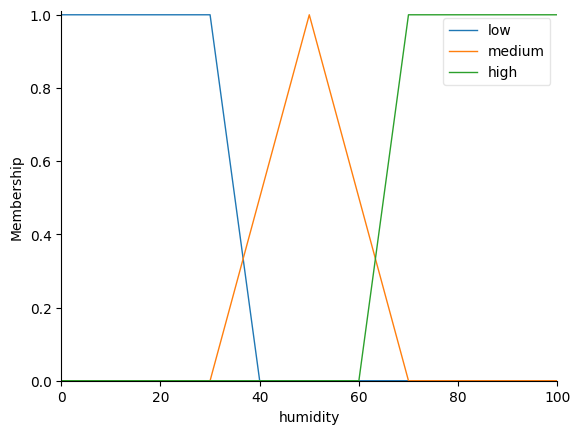

In [ ]:
humidity.view()

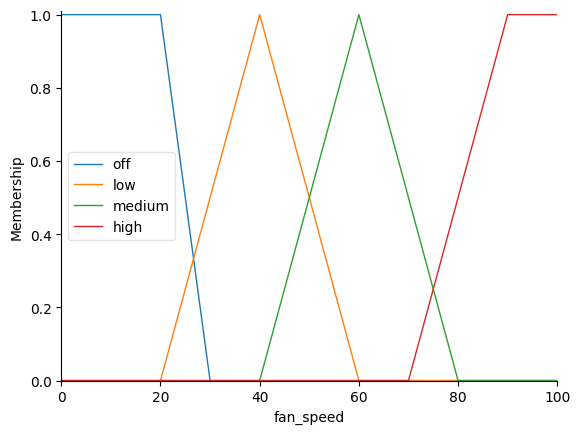

In [ ]:
fan_speed.view()

In [ ]:
# Reglas
# Si la temperatura es fria y la humedad es baja el ventilador va a estar off
rule1 = ctrl.Rule(temperature['cold'] & humidity['low'], fan_speed['off'])
# Si la temperatura es fria y la humedad media la velocidad va a estar baja
rule2 = ctrl.Rule(temperature['cold'] & humidity['medium'], fan_speed['low'])
# Si la temperatura es fria y la humedad alta la velocidad va a estar baja
rule3 = ctrl.Rule(temperature['cold'] & humidity['high'], fan_speed['low'])
# Si la temperatura es calida y la humedad va a estar baja la velocidad va a estar baja
rule4 = ctrl.Rule(temperature['warm'] & humidity['low'], fan_speed['low'])
# Si la temperatura es calida y la humedad va a estar media entonces la velocidad va a estar media
rule5 = ctrl.Rule(temperature['warm'] & humidity['medium'], fan_speed['medium'])
# Si la temperatura es calida y la humedad alta entonces la velocidad va a estar alta
rule6 = ctrl.Rule(temperature['warm'] & humidity['high'], fan_speed['high'])
# Si la temperatura es calurosa y la humedad es baja entonces la velocidad va a estar alta
rule7 = ctrl.Rule(temperature['hot'] & humidity['low'], fan_speed['high'])
# Si la temperatura es calurosa y la humedad media entonces la velocidad va a estar alta
rule8 = ctrl.Rule(temperature['hot'] & humidity['medium'], fan_speed['high'])
# Si la temperatura es calurosa y la humedad es alta entonces la velocidad va a estar alta
rule9 = ctrl.Rule(temperature['hot'] & humidity['high'], fan_speed['high'])

In [ ]:
# Sistema de control
fan_control = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
fan_simulation = ctrl.ControlSystemSimulation(fan_control)

# Entradas
fan_simulation.input['temperature'] = 25
fan_simulation.input['humidity'] = 65

# Computa la salida
fan_simulation.compute()

Velocidad del ventilador: 76.14583333333333


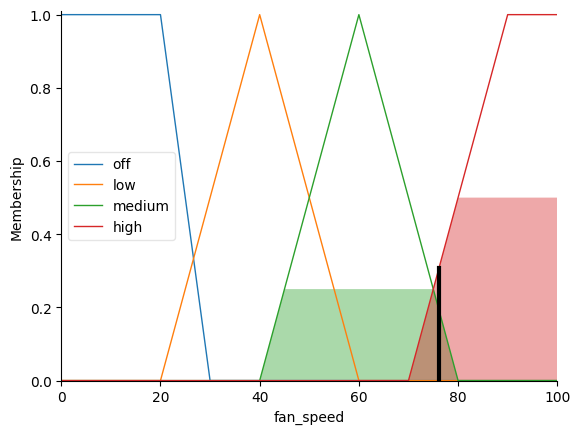

In [ ]:
print(f"Velocidad del ventilador: {fan_simulation.output['fan_speed']}")
fan_speed.view(sim=fan_simulation)